IS362 FINAL PROJECT: Smartphone Usage and Addiction Analysis

This project will explore which screen time factors highlight addiction, impact sleep and productivity and identify behavioral patterns for high risk users.

Import the necessary libraries

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

Load the data set from Kaggle, identify missing values and remove duplicates

In [36]:
df = pd.read_csv("Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")

print("\nMissing Values:")
print(df.isnull().sum())


df.drop_duplicates(inplace=True)

print("\nDataset Shape After Removing Duplicates:")
print(df.shape)


Missing Values:
transaction_id               0
user_id                      0
age                          0
gender                       0
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                  0
notifications_per_day        0
app_opens_per_day            0
weekend_screen_time          0
stress_level                 0
academic_work_impact         0
addiction_level            819
addicted_label               0
dtype: int64

Dataset Shape After Removing Duplicates:
(7500, 16)


Upload API data source and simulate an API response

In [37]:
url = "https://api.screentimeapi.com/v1/usage"

api_data = {
    "users": [
        {"user_id": 1, "daily_screen_time": 7.5, "notifications": 120, "social_media_hours": 4.2},
        {"user_id": 2, "daily_screen_time": 3.1, "notifications": 45, "social_media_hours": 1.5},
        {"user_id": 3, "daily_screen_time": 9.0, "notifications": 200, "social_media_hours": 5.8},
        {"user_id": 4, "daily_screen_time": 5.2, "notifications": 85, "social_media_hours": 2.9},
        {"user_id": 5, "daily_screen_time": 8.3, "notifications": 160, "social_media_hours": 4.9},
        {"user_id": 6, "daily_screen_time": 2.8, "notifications": 30, "social_media_hours": 1.0},
        {"user_id": 7, "daily_screen_time": 6.5, "notifications": 110, "social_media_hours": 3.7},
        {"user_id": 8, "daily_screen_time": 4.0, "notifications": 70, "social_media_hours": 2.1},
        {"user_id": 9, "daily_screen_time": 10.2, "notifications": 250, "social_media_hours": 6.5},
        {"user_id": 10, "daily_screen_time": 5.9, "notifications": 95, "social_media_hours": 3.0}
    ]
}

 Convert API data into DataFrame

In [38]:
api_df = pd.DataFrame(api_data['users'])

print("\nAPI Data:")
print(api_df)


API Data:
   user_id  daily_screen_time  notifications  social_media_hours
0        1                7.5            120                 4.2
1        2                3.1             45                 1.5
2        3                9.0            200                 5.8
3        4                5.2             85                 2.9
4        5                8.3            160                 4.9
5        6                2.8             30                 1.0
6        7                6.5            110                 3.7
7        8                4.0             70                 2.1
8        9               10.2            250                 6.5
9       10                5.9             95                 3.0


Now we perform Data Tranformation and create Screen Time Categories

In [39]:
df['screen_time_category'] = pd.cut(
    df['daily_screen_time_hours'],
    bins=[0, 3, 6, 9, 24],
    labels=['Low', 'Moderate', 'High', 'Extreme']
)

print("\nScreen Time Categories:")
print(df[['daily_screen_time_hours', 'screen_time_category']].head())


Screen Time Categories:
   daily_screen_time_hours screen_time_category
0                     3.23             Moderate
1                     5.09             Moderate
2                     6.06                 High
3                     7.83                 High
4                     9.96              Extreme


Create a smart phone risk score and risk levels to provide more insight on what factors have the highest impact

In [40]:
df['risk_score'] = (
    df['daily_screen_time_hours'] * 2
    + df['social_media_hours'] * 3
    + df['notifications_per_day'] * 0.02
)

print("\nRisk Scores:")
print(df[['risk_score']].head())

df['risk_level'] = pd.cut(
    df['risk_score'],
    bins=[0, 15, 30, 45, 100],
    labels=['Low', 'Moderate', 'High', 'Extreme']
)

print("\nRisk Levels:")
print(df[['risk_score', 'risk_level']].head())


Risk Scores:
   risk_score
0       17.45
1       24.15
2       17.08
3       36.77
4       40.40

Risk Levels:
   risk_score risk_level
0       17.45   Moderate
1       24.15   Moderate
2       17.08   Moderate
3       36.77       High
4       40.40       High


Aggreate the data for clarity

In [41]:
grouped = df.groupby('addiction_level')[
    [
        'daily_screen_time_hours',
        'sleep_hours',
        'social_media_hours'
    ]
].mean()

print("\nAverage Metrics by Addiction Level:")
print(grouped)


Average Metrics by Addiction Level:
                 daily_screen_time_hours  sleep_hours  social_media_hours
addiction_level                                                          
Mild                            5.535062     6.660153            2.258128
Moderate                        8.351427     6.756816            3.579694
Severe                          8.604560     6.778673            3.832190


With all the data tidying and grouping, we will proceed to create our visuslizations

1. Histogram: Daily Screen Time Distribution

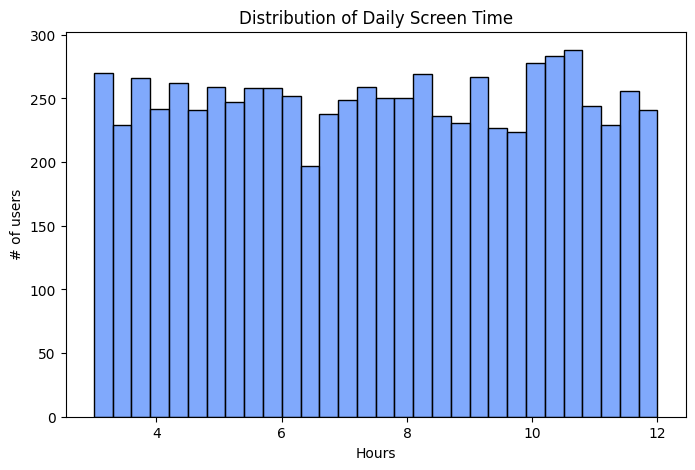

In [42]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['daily_screen_time_hours'],
    bins=30
)

plt.title('Distribution of Daily Screen Time')
plt.xlabel('Hours')
plt.ylabel('# of users')

plt.show()

2. Bar Graph for addiction level distribution

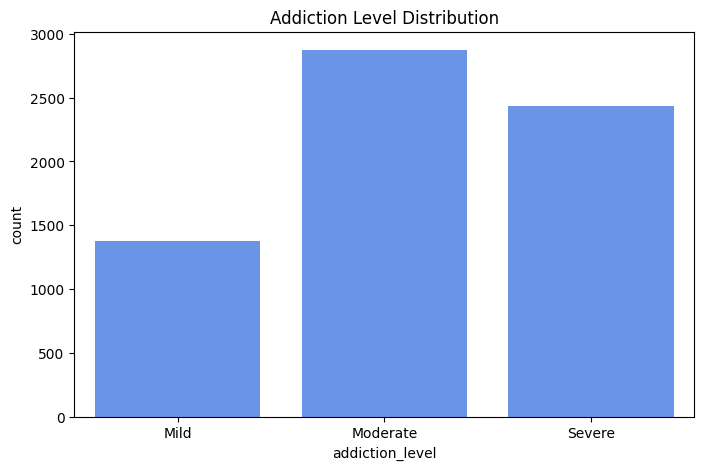

In [43]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='addiction_level',
    data=df
)

plt.title('Addiction Level Distribution')

plt.show()

Now, we compare hours of sleep to addiction levels via a box plot

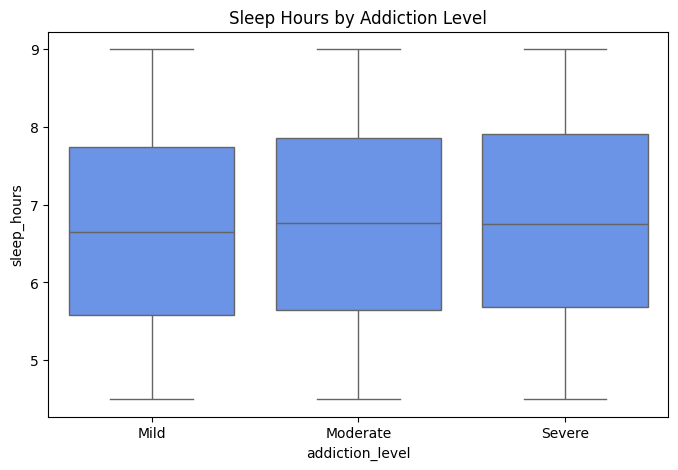

In [44]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='addiction_level',
    y='sleep_hours',
    data=df
)

plt.title('Sleep Hours by Addiction Level')

plt.show()


After the visuliation, we will perform a statisical analysis via a correlation matrix and test.

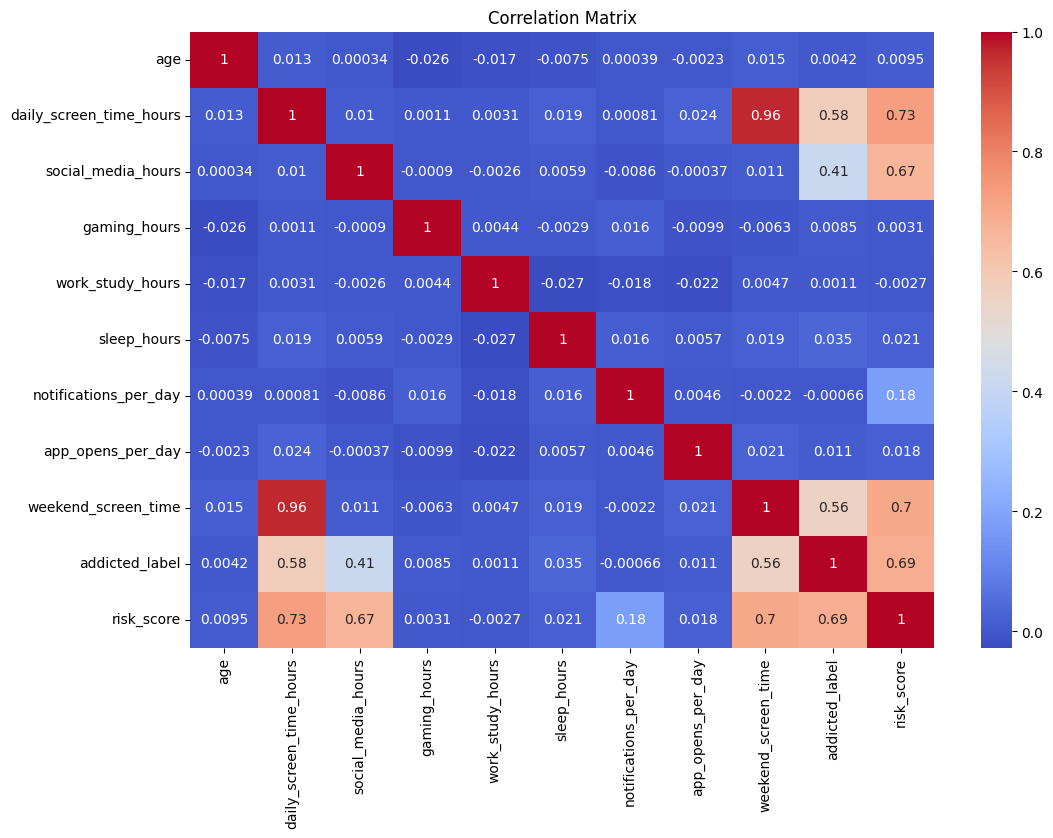


Correlation Between Screen Time and Sleep Hours:
0.019343243519447162


In [45]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

correlation_value = df['daily_screen_time_hours'].corr(
    df['sleep_hours']
)

print("\nCorrelation Between Screen Time and Sleep Hours:")
print(correlation_value)

Then we guage the risk level via users and the risk from low to extreme

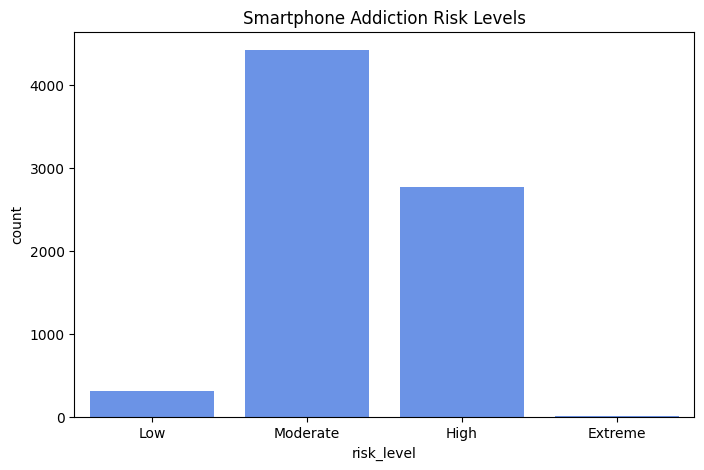

In [46]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='risk_level',
    data=df
)

plt.title('Smartphone Addiction Risk Levels')

plt.show()


We will also create a data visualization for the API

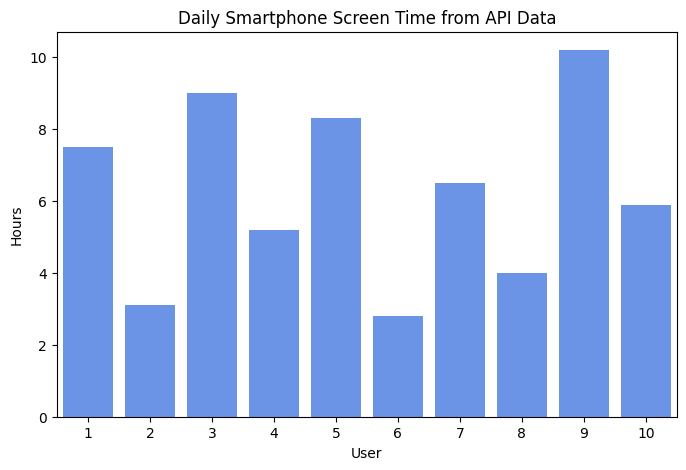

In [49]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='user_id',
    y='daily_screen_time',
    data=api_df
)

plt.title('Daily Smartphone Screen Time from API Data')
plt.xlabel('User')
plt.ylabel('Hours')

plt.show()

In conclusion:
The higher daily screen time is associated with higher smartphone addiction levels.
Increased social media usage contributes significantly to addiction risk.
Higher addiction levels are associated with lower sleep hours.
Notification frequency contributes to distraction behavior.
The custom risk scoring system successfully categorized users into different smartphone addiction risk levels.
The Screen Time API Project demonstrates how real-world smartphone behavioral data can be integrated into analytics workflows.
